# 05 - Visualisations + map + comparison to HDI (ALI 2022)

This notebook:
- creates choropleth maps for ALI and pillars (CP, EO, QOL)
- exports static PNGs for report and a interactive HTML file
- produces bottom-20 chart
- links ALI to another index (HDI) and compares (scatter + correlations)

**Inputs**
- `data/processed/ali_2022_index.csv`
- `data/raw/hdi.csv` (must include ISO3 codes and an HDI value)

**Outputs**
- `outputs/ali_2022_map.html`
- `outputs/figures/ali_map.png`
- `outputs/figures/cp_map.png`, `outputs/figures/eo_map.png`, `outputs/figures/qol_map.png`
- `outputs/figures/clusters_map.png`
- `outputs/figures/ali_bottom20.png`
- `outputs/figures/ali_vs_hdi.png`
- `data/processed/ali_hdi_comparison.csv`

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.io as pio

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# Make plotly render in notebook
pio.renderers.default = "notebook_connected"

FIG_DIR = "../outputs/figures"
DATA_PROC = "../data/processed"
DATA_RAW = "../data/raw"

os.makedirs(FIG_DIR, exist_ok=True)

In [16]:
ali_path = os.path.join(DATA_PROC, "ali_2022_index.csv")
ali = pd.read_csv(ali_path)

# Basic cleanup
ali["iso3"] = ali["iso3"].astype(str).str.strip().str.upper()
ali["country"] = ali["country"].astype(str).str.strip()

print("ALI rows:", len(ali))
print("ALI columns:", ali.columns.tolist())

required_cols = ["iso3", "country", "ALI", "ALI_rank", "CP", "EO", "QOL"]
missing = [c for c in required_cols if c not in ali.columns]
if missing:
    raise ValueError(f"ALI file is missing required columns: {missing}")

ali.head()

ALI rows: 209
ALI columns: ['country', 'iso3', 'year', 'cluster', 'ALI', 'ALI_rank', 'CP', 'EO', 'QOL', 'gdp_pc_log_norm', 'unemployment_rate_norm', 'labor_force_participation_norm', 'life_expectancy_norm', 'ppp_conv_log_norm']


,country,iso3,year,cluster,ALI,ALI_rank,CP,EO,QOL,gdp_pc_log_norm,unemployment_rate_norm,labor_force_participation_norm,life_expectancy_norm,ppp_conv_log_norm
0,Aruba,ABW,2022,1,83.871315,54,93.119150,72.670308,85.824488,74.674022,85.190222,58.146681,85.824488,93.119150
1,Afghanistan,AFG,2022,0,59.369213,184,75.797184,32.346333,69.964120,13.422431,61.559628,22.056941,69.964120,75.797184
2,Angola,AGO,2022,2,61.142967,168,53.291216,62.223197,67.914486,44.418659,61.493589,80.757344,67.914486,53.291216
3,Albania,ALB,2022,3,73.581380,120,67.342313,63.775577,89.626252,60.313892,70.681305,60.331533,89.626252,67.342313
4,Andorra,AND,2022,1,87.200862,27,96.565810,67.566302,97.470474,84.842317,69.677199,48.179389,97.470474,96.565810


In [ ]:
def choropleth(df, value_col, title, colorscale="Viridis"):
    hover_data = {}

    # Always include these if present
    for c, fmt in [
        (value_col, ":.2f"),
        ("ALI_rank", True),
        ("ALI", ":.2f"),
        ("CP", ":.2f"),
        ("EO", ":.2f"),
        ("QOL", ":.2f"),
        ("cluster", True),
    ]:
        if c in df.columns:
            hover_data[c] = fmt

    fig = px.choropleth(
        df,
        locations="iso3",
        color=value_col,
        hover_name="country",
        hover_data=hover_data,
        color_continuous_scale=colorscale,
        title=title,
    )
    fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
    return fig


def write_plotly_png(fig, out_path, scale=2):

    try:
        fig.write_image(out_path, scale=scale)
    except Exception as e:
        raise RuntimeError(
            "Plotly PNG export failed."
            f"Original error: {repr(e)}"
        )

In [ ]:
fig_ali = choropleth(
    ali,
    "ALI",
    "Affordable Liveability Index (ALI), 2022",
    colorscale="Viridis"
)

fig_ali.show()

html_path = "../outputs/ali_2022_map.html"
fig_ali.write_html(html_path)
print("Wrote:", html_path)

png_path = os.path.join(FIG_DIR, "ali_map.png")
write_plotly_png(fig_ali, png_path, scale=2)
print("Wrote:", png_path)

Wrote: ../outputs/ali_2022_map.html
Wrote: ../outputs/figures\ali_map.png


In [ ]:
fig_cp = choropleth(ali, "CP", "Cost Pressure pillar (higher = more affordable), 2022", colorscale="Blues")
fig_eo = choropleth(ali, "EO", "Economic Opportunity pillar, 2022", colorscale="Greens")
fig_qol = choropleth(ali, "QOL", "Quality of Life pillar, 2022", colorscale="Purples")

# Optional display
# fig_cp.show()
# fig_eo.show()
# fig_qol.show()

paths = {
    "cp": os.path.join(FIG_DIR, "cp_map.png"),
    "eo": os.path.join(FIG_DIR, "eo_map.png"),
    "qol": os.path.join(FIG_DIR, "qol_map.png"),
}

write_plotly_png(fig_cp, paths["cp"], scale=2)
write_plotly_png(fig_eo, paths["eo"], scale=2)
write_plotly_png(fig_qol, paths["qol"], scale=2)

print("Wrote:", paths)

Wrote: {'cp': '../outputs/figures\\cp_map.png', 'eo': '../outputs/figures\\eo_map.png', 'qol': '../outputs/figures\\qol_map.png'}


In [ ]:
if "cluster" in ali.columns:
    cl = ali.copy()
    cl["cluster"] = cl["cluster"].astype("Int64").astype(str)  # categorical labels

    fig_cl = px.choropleth(
        cl,
        locations="iso3",
        color="cluster",
        hover_name="country",
        title="K-means clusters (k=4), 2022",
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    fig_cl.update_layout(margin=dict(l=0, r=0, t=50, b=0))
    fig_cl.show()

    cl_path = os.path.join(FIG_DIR, "clusters_map.png")
    write_plotly_png(fig_cl, cl_path, scale=2)
    print("Wrote:", cl_path)
else:
    print("No 'cluster' column found - skipping cluster map.")

Wrote: ../outputs/figures\clusters_map.png


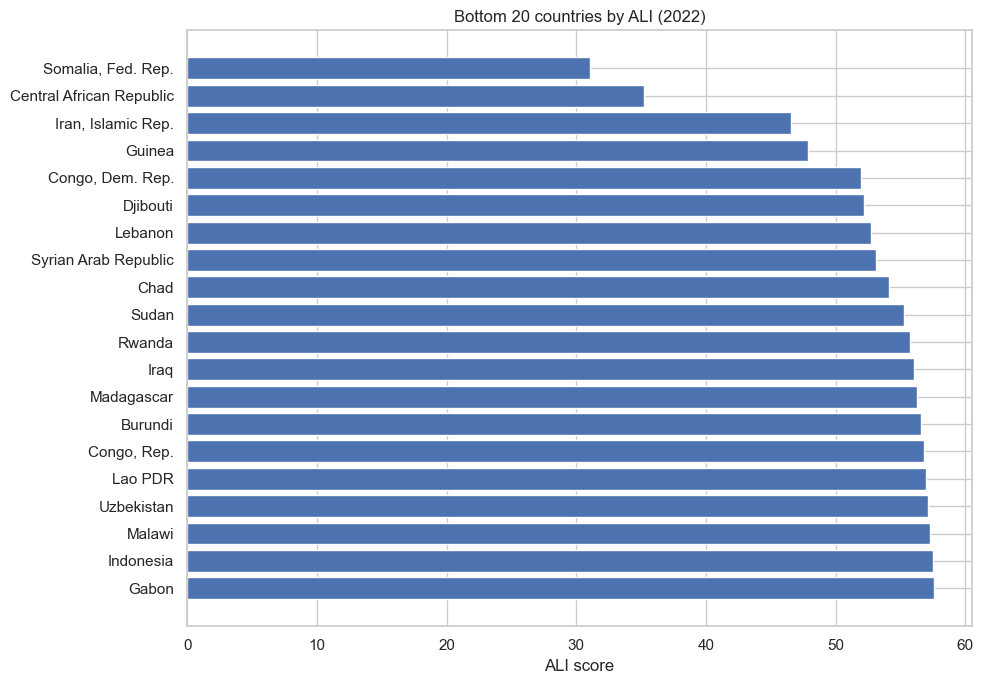

Wrote: ../outputs/figures\ali_bottom20.png


In [21]:
bottomn = 20
plot_df = ali.sort_values("ALI", ascending=True).head(bottomn)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["country"], plot_df["ALI"])
plt.title(f"Bottom {bottomn} countries by ALI (2022)")
plt.xlabel("ALI score")
plt.gca().invert_yaxis()
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "ali_bottom20.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Wrote:", fig_path)

In [22]:
hdi_path = os.path.join(DATA_RAW, "hdi.csv")
hdi = pd.read_csv(hdi_path)

# Normalize iso3
if "iso3" not in hdi.columns:
    raise ValueError("HDI file must include an 'iso3' column.")

hdi["iso3"] = hdi["iso3"].astype(str).str.strip().str.upper()

# Ensure numeric hdi_2022
if "hdi_2022" not in hdi.columns:
    raise ValueError("HDI file must include 'hdi_2022'.")

hdi["hdi_2022"] = pd.to_numeric(hdi["hdi_2022"], errors="coerce")

# Keep optional columns if present
keep_cols = [c for c in ["iso3", "country", "hdi_2022", "tier_hdi", "hdi_rank"] if c in hdi.columns]
hdi = hdi[keep_cols].copy()

print("HDI rows:", len(hdi))
hdi.head()

HDI rows: 195


,iso3,country,hdi_2022,tier_hdi,hdi_rank
0,CHE,Switzerland,0.967,Very High,1.0
1,NOR,Norway,0.966,Very High,2.0
2,ISL,Iceland,0.959,Very High,3.0
3,HKG,"Hong Kong, China (SAR)",0.956,Very High,4.0
4,DNK,Denmark,0.952,Very High,5.0


In [ ]:
df_cmp = ali.merge(
    hdi,
    on="iso3",
    how="left",
    suffixes=("_ali", "_hdi")
)

df_cmp_nonnull = df_cmp.dropna(subset=["hdi_2022"]).copy()

print("Rows ALI:", len(ali))
print("Rows with HDI:", len(df_cmp_nonnull))

# quick check of unmatched iso3s
unmatched = df_cmp[df_cmp["hdi_2022"].isna()]["iso3"].unique()
print("Unmatched ISO3 count:", len(unmatched))

Rows ALI: 209
Rows with HDI: 192
Unmatched ISO3 count: 17


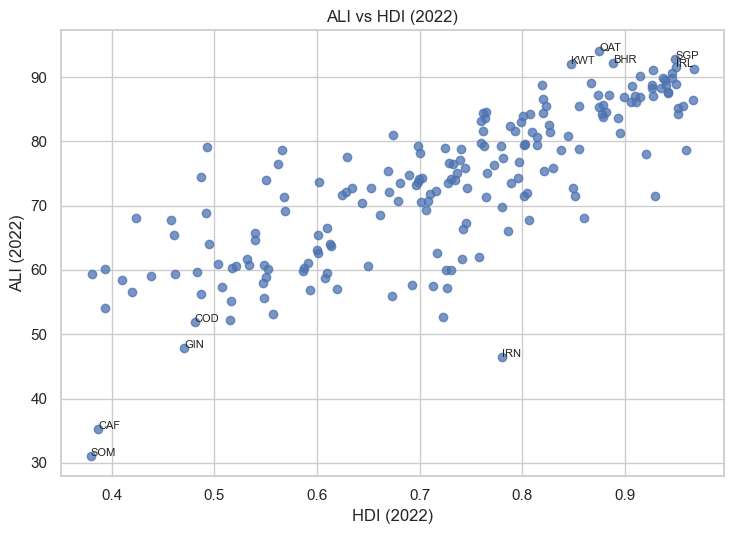

Wrote: ../outputs/figures\ali_vs_hdi.png


In [24]:
plt.figure(figsize=(7.5, 5.5))
plt.scatter(df_cmp_nonnull["hdi_2022"], df_cmp_nonnull["ALI"], alpha=0.75)

plt.xlabel("HDI (2022)")
plt.ylabel("ALI (2022)")
plt.title("ALI vs HDI (2022)")

# annotate extremes (top ALI and bottom ALI)
to_annotate = pd.concat([
    df_cmp_nonnull.nlargest(5, "ALI"),
    df_cmp_nonnull.nsmallest(5, "ALI"),
]).drop_duplicates(subset=["iso3"])

for _, r in to_annotate.iterrows():
    plt.text(r["hdi_2022"], r["ALI"], r["iso3"], fontsize=8)

plt.tight_layout()

out_path = os.path.join(FIG_DIR, "ali_vs_hdi.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Wrote:", out_path)

In [25]:
pearson = df_cmp_nonnull["ALI"].corr(df_cmp_nonnull["hdi_2022"], method="pearson")
spearman = df_cmp_nonnull["ALI"].corr(df_cmp_nonnull["hdi_2022"], method="spearman")

print("Correlation ALI vs HDI (Pearson): ", pearson)
print("Correlation ALI vs HDI (Spearman):", spearman)

Correlation ALI vs HDI (Pearson):  0.7973061225996905
Correlation ALI vs HDI (Spearman): 0.8168290518577124


In [26]:
out_cols = []
for c in ["country", "country_ali", "iso3", "ALI", "ALI_rank", "cluster", "hdi_2022", "hdi_rank", "tier_hdi"]:
    if c in df_cmp_nonnull.columns:
        out_cols.append(c)

cmp_out = df_cmp_nonnull[out_cols].sort_values("ALI_rank").copy()

out_csv = os.path.join(DATA_PROC, "ali_hdi_comparison.csv")
cmp_out.to_csv(out_csv, index=False)
print("Wrote:", out_csv)

cmp_out.head(10)

Wrote: ../data/processed\ali_hdi_comparison.csv


,country_ali,iso3,ALI,ALI_rank,cluster,hdi_2022,hdi_rank,tier_hdi
156,Qatar,QAT,94.107537,1,1,0.875,40.0,Very High
163,Singapore,SGP,92.810383,2,1,0.949,9.0,Very High
18,Bahrain,BHR,92.114896,3,1,0.888,34.0,Very High
103,Kuwait,KWT,92.001814,4,1,0.847,49.0,Very High
87,Ireland,IRL,91.498136,5,1,0.950,7.0,Very High
32,Switzerland,CHE,91.265568,6,1,0.967,1.0,Very High
112,Luxembourg,LUX,91.104282,7,1,0.927,20.0,Very High
137,Netherlands,NLD,90.585893,8,1,0.946,10.0,Very High
123,Malta,MLT,90.150366,9,1,0.915,25.0,Very High
9,Australia,AUS,89.901959,10,1,0.946,10.0,Very High


In [27]:
unmatched = (
    df_cmp[df_cmp["hdi_2022"].isna()][["country_ali", "iso3", "ALI", "ALI_rank"]]
    .sort_values("ALI_rank")
)

unmatched.to_csv("../data/processed/ali_hdi_unmatched.csv", index=False)
print(unmatched.head(20))
print("Unmatched ISO3 count:", len(unmatched))

                   country_ali iso3        ALI  ALI_rank
23                     Bermuda  BMU  87.822051        21
114           Macao SAR, China  MAC  87.576719        23
33             Channel Islands  CHI  87.448139        25
46              Cayman Islands  CYM  86.891731        30
155           French Polynesia  PYF  85.873575        37
177  Sint Maarten (Dutch part)  SXM  84.144091        51
78                        Guam  GUM  84.001599        52
0                        Aruba  ABW  83.871315        54
200      Virgin Islands (U.S.)  VIR  83.845806        55
180   Turks and Caicos Islands  TCA  83.467682        59
204                     Kosovo  XKX  83.432960        60
64               Faroe Islands  FRO  83.270508        61
45                     Curacao  CUW  83.252363        62
150           Puerto Rico (US)  PRI  83.027623        65
151  Korea, Dem. People's Rep.  PRK  82.231661        68
133              New Caledonia  NCL  79.870166        77
76                   Greenland 